# Installing and using the bagelR package

## Installing bagelR

The **bagelR** package can be installed via an interactive **R** session using the following code.

In [1]:
if(system.file(package = "bagelR") != "")
    {
      remove.packages("bagelR")
    }
library("remotes")
install_github("grosed/bagel/bagelR",force=TRUE)

Removing package from ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)




Running `R CMD build`...



* checking for file ‘/tmp/RtmpfbNQeA/remotes3b37305cdcadfb/grosed-bagel-6b19dc4/bagelR/DESCRIPTION’ ... OK
* preparing ‘bagelR’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* installing the package to process help pages
* saving partial Rd database
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘bagelR_1.0.0.tar.gz’


Installing package into ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)



## Check package version

In [2]:
packageVersion("bagelR")

[1] ‘1.0.0’

## Using bagelR - 1 : Detecting Change in Slope with Known Variance

### Example 1 - no change

#### Load the bagel package

In [3]:
library(bagelR)


Attaching package: ‘bagelR’


The following object is masked from ‘package:stats’:

    time




#### Generate some data - no change

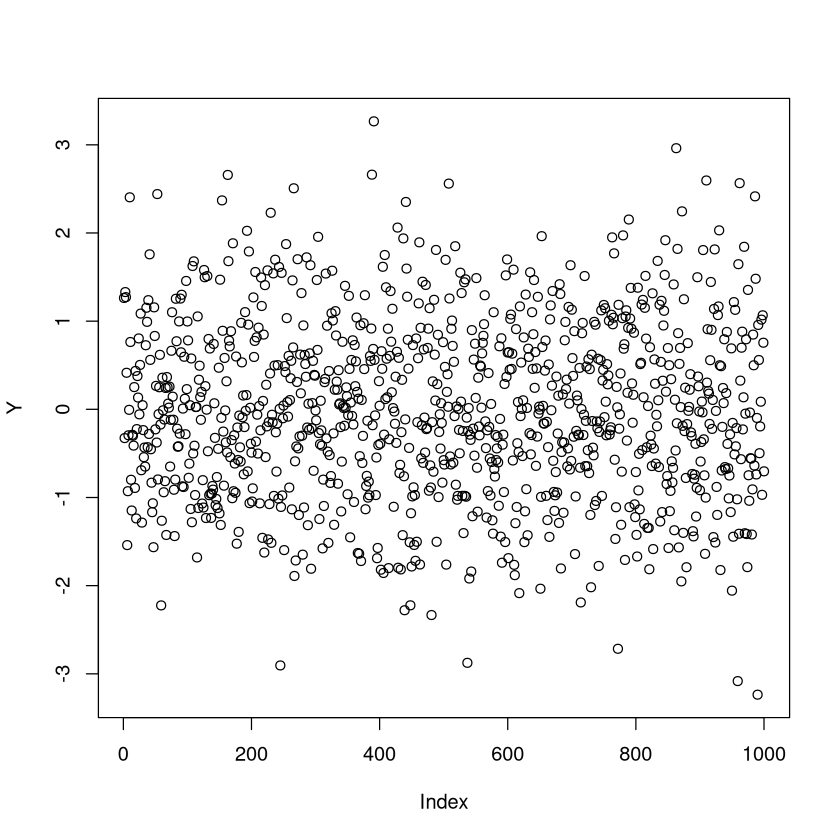

In [37]:
set.seed(0)
Y <- rnorm(1000,0,1)
plot(Y)

#### Define the feature vector function 

These functions for the **feature vector** and the **prior** correspeond to example 2 in "**Bagel : A Fast Baysian Online Changepoint Detection Algorithm for Linear Models**" *Fearnhead et al.*

In [5]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
     M <- matrix(c(0),nc=1,nr=2)	  
     M[1,1] <- 1
     M[2,1] <- t
     return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=4)	  
    M[1,1] <- 1
    M[2,1] <- t
    if(t > tau)
    {
      M[3,1] <- 1
      M[4,1] <- t
    }
  return(M)
  }
}

#### Define the prior function

In [6]:
prior <- function(t)
{
  if(t == 1)
  {
     mu <- matrix(c(0),nc=1,nr=2)
     sigma <- diag(2)
     return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(0),nc=1,nr=4)
  sigma <- diag(4)
  sigma[3,3] <- (t-1)*(t-1)
  sigma[4,3] <- sigma[3,4] <- -(t-1)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Set model parameters 

In [49]:
p <- 1.0;
p0 <- 0.9;
s <- 1.0;
n <- 500

#### Create a new bagel model

In [39]:
model <- bagel(feature_vector,prior,p0,p,s,n)

#### Set up storage for results

In [40]:
w0s <- c()

#### Analyse the data as if running online

In [41]:
for(y in Y)
{
  # update the model with the most recent data and store the weight at tau = 0  
  w0 <- update(model,y)
  w0s <- c(w0s,w0) # log the result  
}

#### Visualise weight at tau = 0

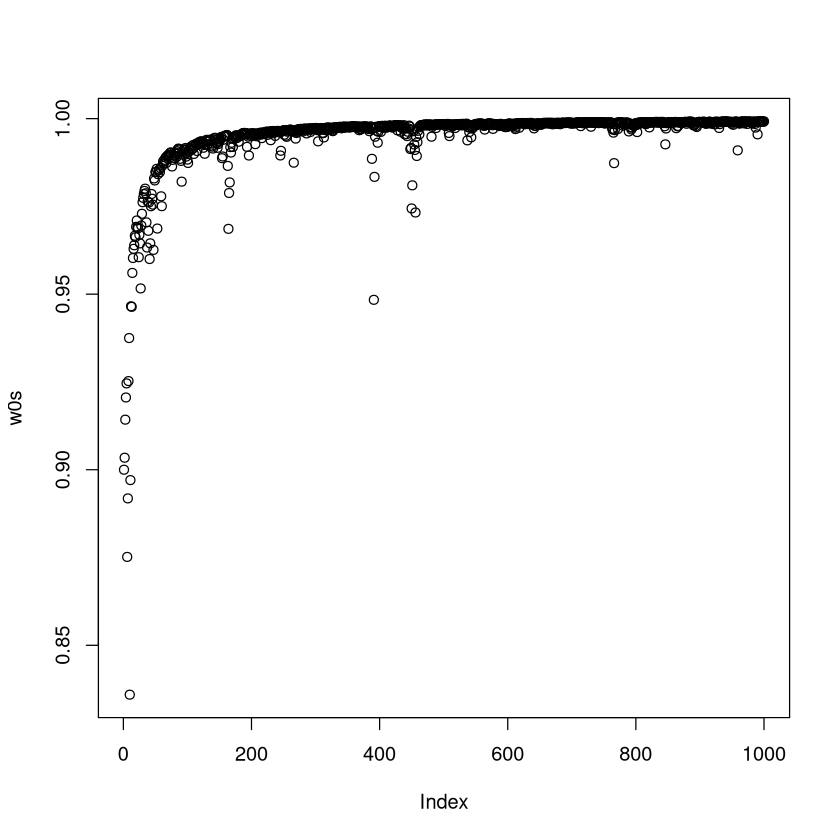

In [42]:
plot(w0s)

### Example 2 - single change in slope

#### Generate data with change in slope at t = 1000

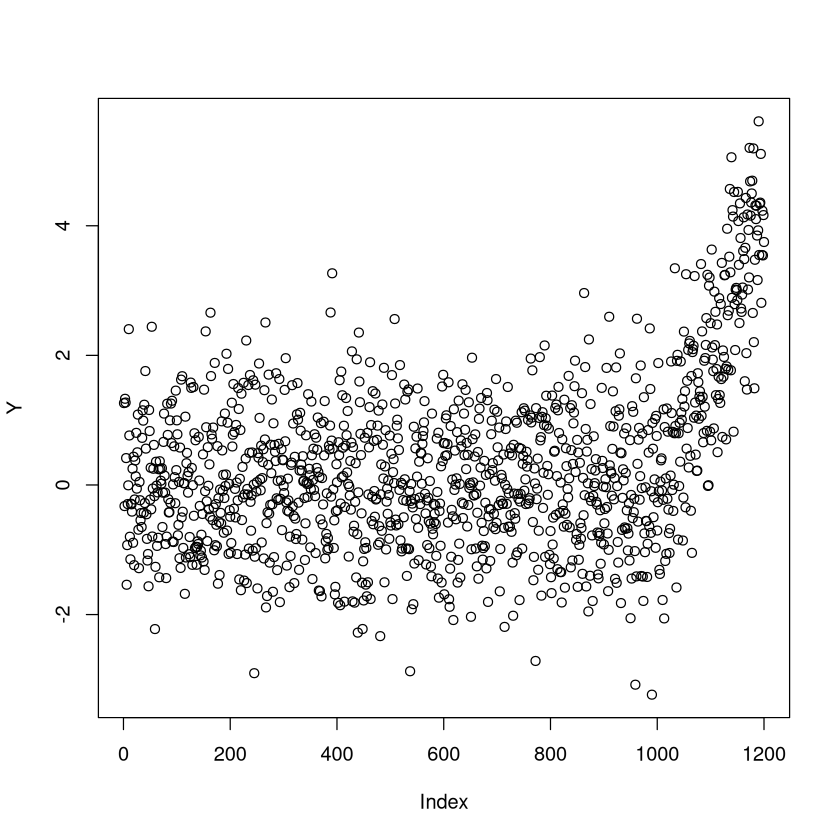

In [43]:
set.seed(0)
Y <- c(rnorm(1000,0,1),seq(1,200,1)/50 + rnorm(200,0,1))
plot(Y)

#### Create new model

In [44]:
model <- bagel(feature_vector,prior,p0,p,s,n)

#### Set up storage for results

In [45]:
w0s <- c()

#### Analyse the data as if running online stopping on change detection

In [46]:
for(y in Y)
{
  # update the model with the most recent data and store the weight at tau = 0  
  w0 <- update(model,y)
  w0s <- c(w0s,w0) # log the result
  if(1 - w0 > 0.8) # stop when threshold for change acheived
      break
}

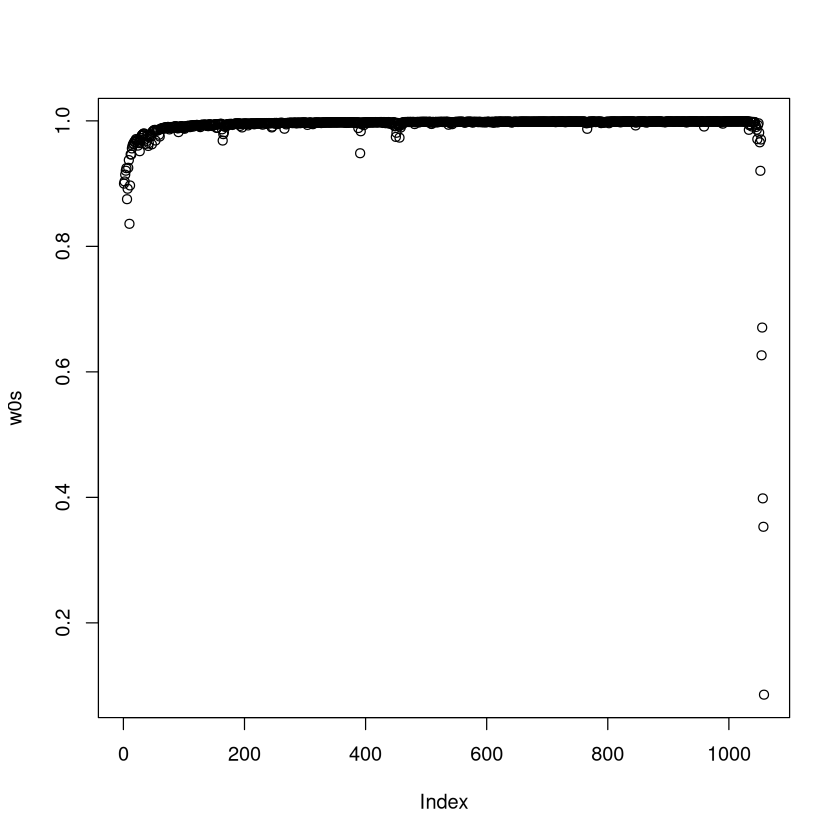

In [47]:
plot(w0s)

#### Determine time at which change wes detected

In [48]:
time(model)

[1] 1059

#### Visulaise weight at tau = 0 around the change point

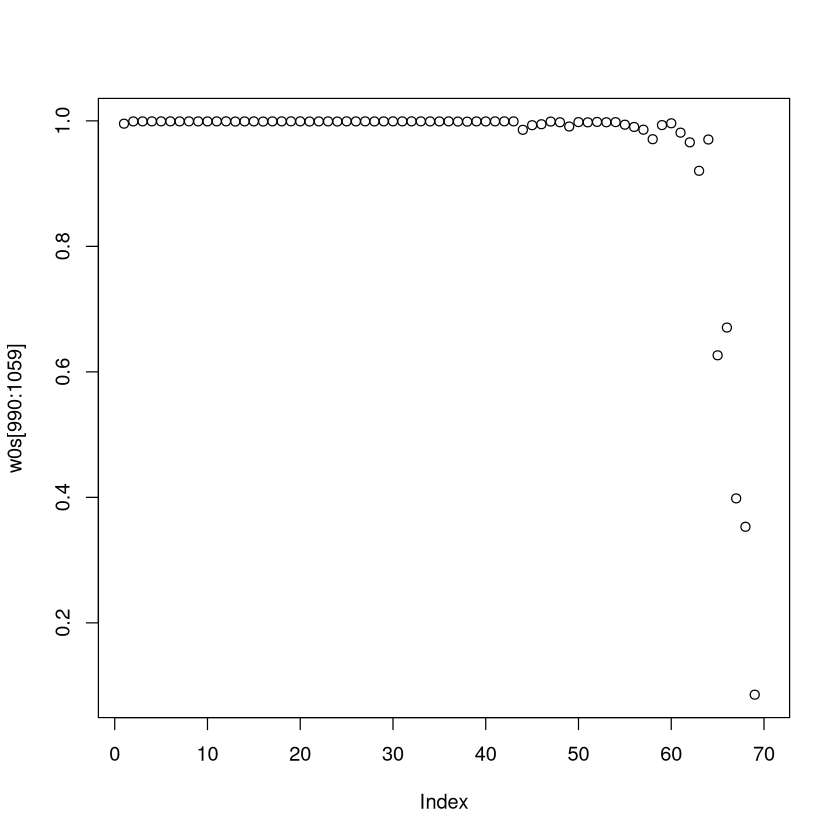

In [34]:
plot(w0s[990:1059])

#### Visulaise the weights after detection of change

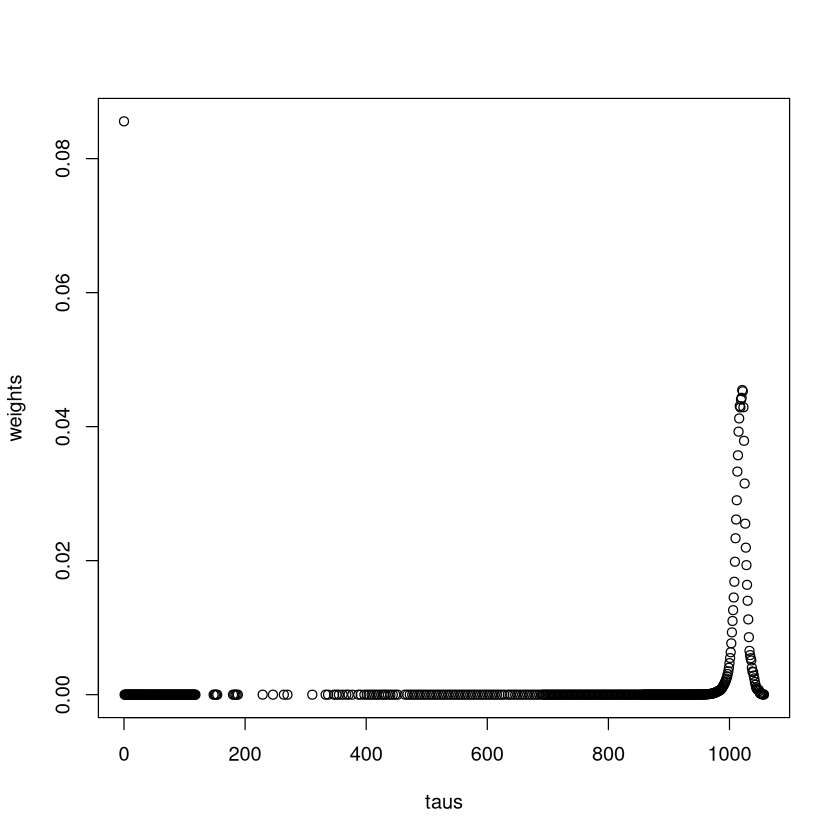

In [35]:
weights <- weights(model)
taus <- taus(model)
plot(taus,weights)

#### Locate the maximum weight for tau > 0

In [36]:
taus[which.max(weights[-1])]

[1] 1020